# 04b — CNN + BatchNorm + Dropout + Data Augmentation (Long Run, 35 Epochs)

**Project:** Progressive CNN Classifier Study
**Stage:** 4b — Follow-up to Notebook 04

### Why this notebook exists
In Notebook 04 (15 epochs), Data Augmentation scored **0.6359 accuracy**, below Notebook 03's 0.7250. But the curves showed both train and validation accuracy still climbing steadily with **no overfitting and no plateau** — a sign of underfitting from insufficient training time, not a bad technique.

This notebook re-runs the exact same model, only increasing epochs from **15 → 35**, to test that hypothesis: does augmentation catch up to (or surpass) Notebook 03 given enough time to converge?

### Scoreboard so far
| Notebook | Technique | Epochs | Test Accuracy | Test Loss |
|---|---|---|---|---|
| 01 | Baseline | 15 | 0.7166 | 0.8821 |
| 02 | + BatchNorm | 15 | 0.6807 | 1.5024 |
| 03 | + BatchNorm + Dropout | 15 | 0.7250 | 0.7805 |
| 04 | + Data Augmentation | 15 | 0.6359 | 1.0204 |
| 04b (this one) | + Data Augmentation | 35 | *TBD* | *TBD* |

### What this notebook covers
- Identical architecture and augmentation pipeline to Notebook 04
- Only change: epochs 15 → 35
- A `ModelCheckpoint` callback to save the *best* validation-accuracy epoch, since a longer run risks overfitting eventually too
- Comparing final results against both Notebook 03 and Notebook 04

## 1. Imports

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Load and Preprocess CIFAR-10

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Build the Augmentation Pipeline

Identical to Notebook 04 — no changes here, so any difference in results is purely due to training duration.

In [3]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

## 4. Build the Full Model

Same architecture as Notebook 04 (BatchNorm + Dropout + Augmentation).

In [4]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,210 (481.29 KB)

 Trainable params: 122,890 (480.04 KB)

 Non-trainable params: 320 (1.25 KB)

## 5. Compile

In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 6. Train (35 Epochs) with Best-Model Checkpointing

**Only real change from Notebook 04:** `epochs=35` instead of `15`.

We also add a `ModelCheckpoint` callback that saves the model only when validation accuracy improves — this protects us in case the model eventually starts overfitting in later epochs (epoch 30 might be worse than epoch 22, for example). This way we always keep the *best* version, not just the last one.

This will take noticeably longer than previous notebooks (roughly 2-2.5x the time of the 15-epoch runs) — let it run fully.

In [6]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

checkpoint_cb = callbacks.ModelCheckpoint(
    "models/augmentation_cnn_longrun_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    x_train, y_train,
    epochs=35,
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=[checkpoint_cb]
)

Epoch 1/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2940 - loss: 2.0305
Epoch 1: val_accuracy improved from None to 0.42290, saving model to models/augmentation_cnn_longrun_best.h5



Epoch 1: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2940 - loss: 2.0305 - val_accuracy: 0.4229 - val_loss: 1.6503
Epoch 2/35
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3901 - loss: 1.6790
Epoch 2: val_accuracy improved from 0.42290 to 0.48930, saving model to models/augmentation_cnn_longrun_best.h5



Epoch 2: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3903 - loss: 1.6785 - val_accuracy: 0.4893 - val_loss: 1.3986
Epoch 3/35
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4294 - loss: 1.5758
Epoch 3: val_accuracy improved from 0.48930 to 0.52820, saving model to models/augmentation_cnn_longrun_best.h5



Epoch 3: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4294 - loss: 1.5756 - val_accuracy: 0.5282 - val_loss: 1.3329
Epoch 4/35
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4537 - loss: 1.5153
Epoch 4: val_accuracy did not improve from 0.52820
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4536 - loss: 1.5153 - val_accuracy: 0.4973 - val_loss: 1.3736
Epoch 5/35
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4726 - loss: 1.4734
Epoch 5: val_accuracy improved from 0.52820 to 0.53310, saving model to models/augmentation_cnn_longrun_best.h5



Epoch 5: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4726 - loss: 1.4735 - val_accuracy: 0.5331 - val_loss: 1.3472
Epoch 6/35
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4875 - loss: 1.4309
Epoch 6: val_accuracy did not improve from 0.53310
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4875 - loss: 1.4308 - val_accuracy: 0.5303 - val_loss: 1.3036
Epoch 7/35
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5023 - loss: 1.3990
Epoch 7: val_accuracy improved from 0.53310 to 0.54970, saving model to models/augmentation_cnn_longrun_best.h5


...


Epoch 18: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.5636 - loss: 1.2498 - val_accuracy: 0.6302 - val_loss: 1.0233
Epoch 19/35
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5670 - loss: 1.2367
Epoch 19: val_accuracy did not improve from 0.63020
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.5669 - loss: 1.2368 - val_accuracy: 0.5937 - val_loss: 1.1597
Epoch 20/35
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5700 - loss: 1.2304
Epoch 20: val_accuracy did not improve from 0.63020
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.5701 - loss: 1.2304 - val_accuracy: 0.5976 - val_loss: 1.1246
Epoch 21/35
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5750 - loss: 1.2264
Epoch 21: val_accuracy did not improve from 0.63020
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.5751 - loss: 1.2263 - val_accuracy: 0.6263 - val_loss: 1.0643
Epoch 22/35
780/782 ━━━━━━━━


Epoch 24: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5818 - loss: 1.2043 - val_accuracy: 0.6424 - val_loss: 1.0140
Epoch 25/35
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5849 - loss: 1.1960
Epoch 25: val_accuracy improved from 0.64240 to 0.65350, saving model to models/augmentation_cnn_longrun_best.h5



Epoch 25: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5850 - loss: 1.1959 - val_accuracy: 0.6535 - val_loss: 0.9750
Epoch 26/35
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5840 - loss: 1.1952
Epoch 26: val_accuracy did not improve from 0.65350
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5841 - loss: 1.1949 - val_accuracy: 0.6376 - val_loss: 1.0232
Epoch 27/35
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5880 - loss: 1.1854
Epoch 27: val_accuracy improved from 0.65350 to 0.66010, saving model to models/augmentation_cnn_longrun_best.h5



Epoch 27: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5880 - loss: 1.1853 - val_accuracy: 0.6601 - val_loss: 0.9604
Epoch 28/35
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5926 - loss: 1.1809
Epoch 28: val_accuracy did not improve from 0.66010
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5926 - loss: 1.1809 - val_accuracy: 0.6304 - val_loss: 1.0498
Epoch 29/35
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5912 - loss: 1.1805
Epoch 29: val_accuracy improved from 0.66010 to 0.66800, saving model to models/augmentation_cnn_longrun_best.h5



Epoch 29: finished saving model to models/augmentation_cnn_longrun_best.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5912 - loss: 1.1805 - val_accuracy: 0.6680 - val_loss: 0.9441
Epoch 30/35
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5926 - loss: 1.1723
Epoch 30: val_accuracy did not improve from 0.66800
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5925 - loss: 1.1725 - val_accuracy: 0.6152 - val_loss: 1.0921
Epoch 31/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5956 - loss: 1.1648
Epoch 31: val_accuracy did not improve from 0.66800
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5956 - loss: 1.1648 - val_accuracy: 0.6340 - val_loss: 1.0424
Epoch 32/35
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5963 - loss: 1.1671
Epoch 32: val_accuracy did not improve from 0.66800
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5963 - loss: 1.1672 - val_accuracy: 0.6179 - val_loss: 1.1117
Epoch 33/35
779/782 ━━━━━━━━

## 7. Load the Best Checkpoint

We evaluate the *best* saved checkpoint (highest validation accuracy seen during training), not necessarily the epoch-35 weights, since those could be slightly overfit compared to an earlier peak.

In [7]:
best_model = tf.keras.models.load_model("models/augmentation_cnn_longrun_best.h5")
print("Best checkpoint loaded.")

Best checkpoint loaded.


## 8. Visualize Training Curves (Full 35 Epochs)

Compare the shape of this curve to Notebook 04's — check whether accuracy has now plateaued (converged) rather than still climbing, and whether a gap between train/val opens up in later epochs (a sign we're approaching the point of diminishing/negative returns from more training).

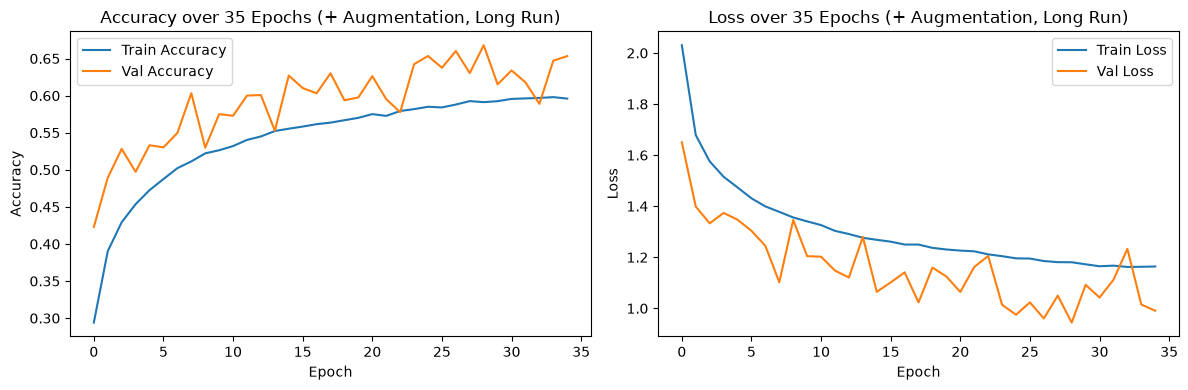

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over 35 Epochs (+ Augmentation, Long Run)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over 35 Epochs (+ Augmentation, Long Run)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("results/augmentation_cnn_longrun_curves.png")
plt.show()

## 9. Final Evaluation (Best Checkpoint)

In [9]:
test_loss, test_acc = best_model.evaluate(x_test, y_test)
print(f"Final Test Accuracy (best checkpoint): {test_acc:.4f}")
print(f"Final Test Loss (best checkpoint): {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6680 - loss: 0.9441
Final Test Accuracy (best checkpoint): 0.6680
Final Test Loss (best checkpoint): 0.9441


## 10. Direct Comparison vs. All Previous Stages

In [10]:
results_table = [
    ("Baseline (01), 15ep", 0.7166, 0.8821),
    ("BatchNorm (02), 15ep", 0.6807, 1.5024),
    ("BatchNorm+Dropout (03), 15ep", 0.7250, 0.7805),
    ("+Augmentation (04), 15ep", 0.6359, 1.0204),
    ("+Augmentation (04b), 35ep", test_acc, test_loss),
]

print(f"{'Model':<32}{'Test Accuracy':<18}{'Test Loss':<12}")
for name, acc, loss in results_table:
    print(f"{name:<32}{acc:<18.4f}{loss:<12.4f}")

print(f"\nAccuracy change vs Notebook 03 (best regularized, 15ep): {test_acc - 0.7250:+.4f}")
print(f"Accuracy change vs Notebook 04 (same model, 15ep): {test_acc - 0.6359:+.4f}")

Model                           Test Accuracy     Test Loss   
Baseline (01), 15ep             0.7166            0.8821      
BatchNorm (02), 15ep            0.6807            1.5024      
BatchNorm+Dropout (03), 15ep    0.7250            0.7805      
+Augmentation (04), 15ep        0.6359            1.0204      
+Augmentation (04b), 35ep       0.6680            0.9441      

Accuracy change vs Notebook 03 (best regularized, 15ep): -0.0570
Accuracy change vs Notebook 04 (same model, 15ep): +0.0321


## Summary & Next Steps

**Question this notebook answers:** was Notebook 04's lower score due to augmentation being a bad fit, or just needing more epochs to converge?

- If **04b's accuracy > 04's accuracy** by a clear margin and the curves show convergence (plateauing) rather than an ongoing climb, that confirms it was purely a training-duration issue, and augmentation is a genuinely useful technique that just needed a fairer comparison.
- If **04b still trails Notebook 03** even after 35 epochs, that's also a valid and interesting finding — it would suggest this particular augmentation strength (rotation/zoom/translation ranges) may be too aggressive for a small, low-resolution dataset like CIFAR-10 (32x32 images have very little detail to begin with, so aggressive geometric distortion may remove more useful signal than it adds as regularization).

Either outcome is a legitimate, reportable result — write down whichever one you observe with the reasoning above.

**Next:** proceed to `05_lr_scheduling.ipynb`, where we add a learning rate schedule/callback on top of the Notebook 03 architecture (BatchNorm + Dropout, no augmentation) so the optimizer takes smaller, more precise steps as training progresses.